In [1]:
import pandas as pd

Data loading

In [2]:
df=pd.read_csv("/content/Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.shape

(10000, 14)

Data cleaning

In [7]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [12]:
df.value_counts('Gender')

,count
Gender,
Male,5457
Female,4543


In [13]:
df.value_counts('Geography')

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [14]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


EDA

In [15]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [16]:
# churn count
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
# churn percentage
churn_percentage=(df["Exited"].value_counts()[1]/df["Exited"].count())*100
churn_percentage

np.float64(20.369999999999997)

In [17]:
# geography wise churn rate
Geography_churn=df.groupby('Geography')['Exited'].mean()*100
Geography_churn

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [18]:
# gender wise churn rate
Gender_churn=df.groupby('Gender')['Exited'].mean()*100
Gender_churn

,Exited
Gender,
Female,25.071539
Male,16.455928


In [19]:
def Age_group(Age):
   if Age<=25:
    return "18-25"
   elif Age<=35:
    return "26-35"
   elif Age<=50:
    return "36-50"
   elif Age<=65:
    return "51-65"
   else:
    return "66+"
df["Age_group"]=df["Age"].apply(Age_group)


In [20]:
df[["Age","Age_group"]].head(10)

,Age,Age_group
0,42,36-50
1,41,36-50
2,42,36-50
3,39,36-50
4,43,36-50
5,44,36-50
6,50,36-50
7,29,26-35
8,44,36-50
9,27,26-35


In [21]:
df['Age_group'].value_counts()


,count
Age_group,
36-50,4586
26-35,3542
51-65,997
18-25,611
66+,264


In [22]:
Age_group_churn=df.groupby('Age_group')['Exited'].mean()*100
Age_group_churn

,Exited
Age_group,
18-25,7.528642
26-35,8.498024
36-50,24.574793
51-65,52.958877
66+,13.257576


In [23]:
# Active member wise churn
Active_churn=df.groupby('IsActiveMember')['Exited'].mean()*100
Active_churn

,Exited
IsActiveMember,
0,26.850897
1,14.269074


In [24]:
# number of product wise churn rate
product_churn=df.groupby('NumOfProducts')['Exited'].mean()*100
product_churn

,Exited
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


In [25]:
# age and geography wise churn rate
age_geo_churn=df.groupby(['Age_group','Geography'])['Exited'].mean()*100
age_geo_churn


Age_group  Geography
18-25      France        5.228758
           Germany      11.188811
           Spain         8.641975
26-35      France        5.788635
           Germany      14.800995
           Spain         8.538012
36-50      France       20.026942
           Germany      38.640133
           Spain        18.647008
51-65      France       48.817204
           Germany      67.465753
           Spain        43.333333
66+        France        9.022556
           Germany      25.000000
           Spain        10.447761
Name: Exited, dtype: float64

In [26]:
df["CreditScore"].max()

850

In [27]:
df["CreditScore"].min()

350

In [28]:
def Credit_score_group(CreditScore):
   if CreditScore<=500:
    return "low"
   elif CreditScore<=650:
    return "medium"
   else:
    return "high"
df["CreditScore_group"]=df["CreditScore"].apply(Credit_score_group)

In [29]:
df[["CreditScore","CreditScore_group"]].head(10)

,CreditScore,CreditScore_group
0,619,medium
1,608,medium
2,502,medium
3,699,high
4,850,high
5,645,medium
6,822,high
7,376,low
8,501,medium
9,684,high


In [30]:
df['CreditScore_group'].value_counts()

,count
CreditScore_group,
high,5063
medium,4294
low,643


In [31]:
# credit score group wise churn rate
df.groupby("CreditScore_group")["Exited"].mean()*100

,Exited
CreditScore_group,
high,19.356113
low,23.639191
medium,21.075920


In [32]:
categorical_cols = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember',
    'NumOfProducts',
    'Tenure',
    'Age_group',
    'CreditScore_group'
]

for col in categorical_cols:
    print(f"\n--- Churn Rate by {col} ---")
    print((df.groupby(col)['Exited'].mean() * 100).round(2))


--- Churn Rate by Geography ---
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

--- Churn Rate by Gender ---
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

--- Churn Rate by HasCrCard ---
HasCrCard
0    20.81
1    20.18
Name: Exited, dtype: float64

--- Churn Rate by IsActiveMember ---
IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64

--- Churn Rate by NumOfProducts ---
NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

--- Churn Rate by Tenure ---
Tenure
0     23.00
1     22.42
2     19.18
3     21.11
4     20.53
5     20.65
6     20.27
7     17.22
8     19.22
9     21.65
10    20.61
Name: Exited, dtype: float64

--- Churn Rate by Age_group ---
Age_group
18-25     7.53
26-35     8.50
36-50    24.57
51-65    52.96
66+      13.26
Name: Exited, dtype: float64

--- Churn Rate by CreditScore_group ---
CreditScore_group
high      19.36
low       23.64
medium    21.08
N

In [33]:
numerical_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

df.groupby('Exited')[numerical_cols].mean().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Exited,,,,,,
0,651.85,37.41,5.03,72745.30,1.54,99738.39
1,645.35,44.84,4.93,91108.54,1.48,101465.68


In [34]:
df["Balance"].agg(['min','max','mean','median'])

,Balance
min,0.000000
max,250898.090000
mean,76485.889288
median,97198.540000


In [35]:
def Balance_group(Balance):
  if Balance==0:
    return "No Balance"
  elif Balance<=50000:
    return "Low"
  elif Balance<=100000:
    return "Medium"
  elif Balance<=150000:
    return "High"
  else:
    return "Very High"
df["Balance_group"]=df["Balance"].apply(Balance_group)

In [36]:
df[["Balance","Balance_group"]].head()

,Balance,Balance_group
0,0.00,No Balance
1,83807.86,Medium
2,159660.80,Very High
3,0.00,No Balance
4,125510.82,High


In [37]:
# Balance wise churn rate
Balance_churn=df.groupby('Balance_group')['Exited'].mean().mul(100).round(2)
Balance_churn

,Exited
Balance_group,
High,25.77
Low,34.67
Medium,19.88
No Balance,13.82
Very High,23.12


In [38]:
df["HasCrCard"].value_counts()

,count
HasCrCard,
1,7055
0,2945


In [39]:
# hascrcard wise churn rate
df.groupby('HasCrCard')['Exited'].mean().mul(100).round(2)

,Exited
HasCrCard,
0,20.81
1,20.18


In [40]:
df.groupby("HasCrCard")["Exited"].sum()

,Exited
HasCrCard,
0,613
1,1424


In [41]:
pd.crosstab(
    [df['Age_group'], df['Geography']],
    df['Exited'],
    normalize='index'
).mul(100).round(2)

Exited                   0      1
Age_group Geography              
18-25     France     94.77   5.23
          Germany    88.81  11.19
          Spain      91.36   8.64
26-35     France     94.21   5.79
          Germany    85.20  14.80
          Spain      91.46   8.54
36-50     France     79.97  20.03
          Germany    61.36  38.64
          Spain      81.35  18.65
51-65     France     51.18  48.82
          Germany    32.53  67.47
          Spain      56.67  43.33
66+       France     90.98   9.02
          Germany    75.00  25.00
          Spain      89.55  10.45

In [42]:
pd.crosstab(
    [df['Age_group'], df['IsActiveMember']],
    df['Exited'],
    normalize='index'
).mul(100).round(2)

Exited                        0      1
Age_group IsActiveMember              
18-25     0               88.89  11.11
          1               95.67   4.33
26-35     0               89.20  10.80
          1               93.73   6.27
36-50     0               69.91  30.09
          1               81.46  18.54
51-65     0               13.23  86.77
          1               69.04  30.96
66+       0               37.50  62.50
          1               93.53   6.47

In [43]:
# credit score group and geography
pd.crosstab(
    [df['CreditScore_group'], df['Geography']],
    df['Exited'],
    normalize='index'
).mul(100).round(2)

Exited                           0      1
CreditScore_group Geography              
high              France     84.93  15.07
                  Germany    68.78  31.22
                  Spain      83.83  16.17
low               France     80.36  19.64
                  Germany    64.94  35.06
                  Spain      81.16  18.84
medium            France     83.08  16.92
                  Germany    66.54  33.46
                  Spain      83.03  16.97

In [44]:
# Balance group and geography
pd.crosstab(
    [df['Balance_group'], df['Geography']],
    df['Exited'],
    normalize='index'
).mul(100).round(2)

Exited                        0      1
Balance_group Geography               
High          France      83.88  16.12
              Germany     60.90  39.10
              Spain       85.33  14.67
Low           France      51.22  48.78
              Germany    100.00   0.00
              Spain       60.00  40.00
Medium        France      83.00  17.00
              Germany     79.39  20.61
              Spain       75.74  24.26
No Balance    France      86.06  13.94
              Spain       86.41  13.59
Very High     France      75.69  24.31
              Germany     80.89  19.11
              Spain       73.54  26.46

In [46]:
df['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


In [45]:
# number of products and active member
pd.crosstab(
    [df['NumOfProducts'], df['IsActiveMember']],
    df['Exited'],
    normalize='index'
).mul(100).round(2)

Exited                            0       1
NumOfProducts IsActiveMember               
1             0               63.35   36.65
              1               81.08   18.92
2             0               90.11    9.89
              1               94.44    5.56
3             0               11.76   88.24
              1               24.78   75.22
4             0                0.00  100.00
              1                0.00  100.00

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

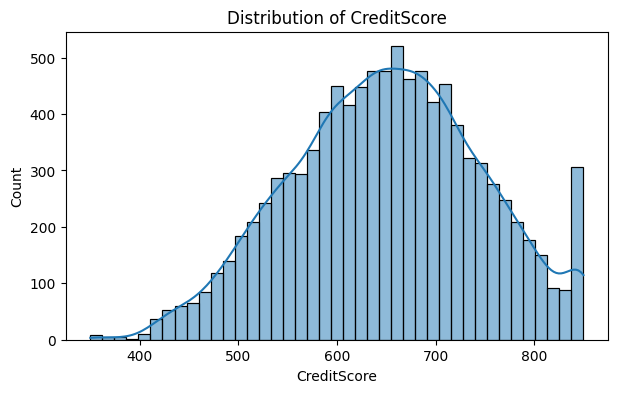

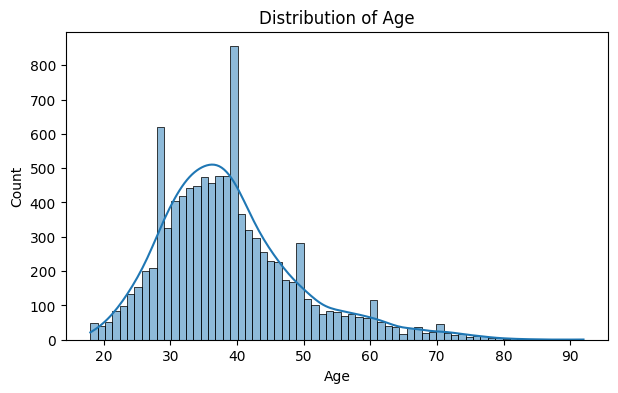

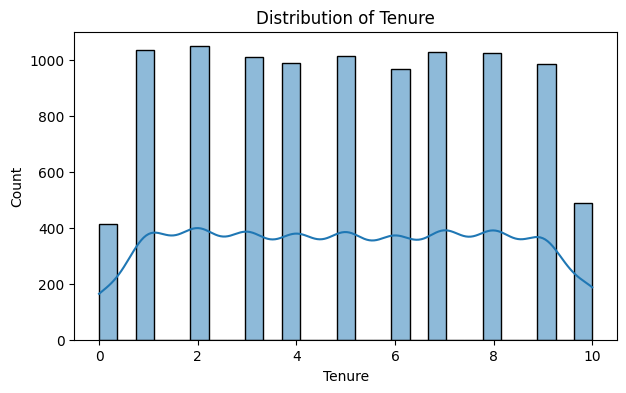

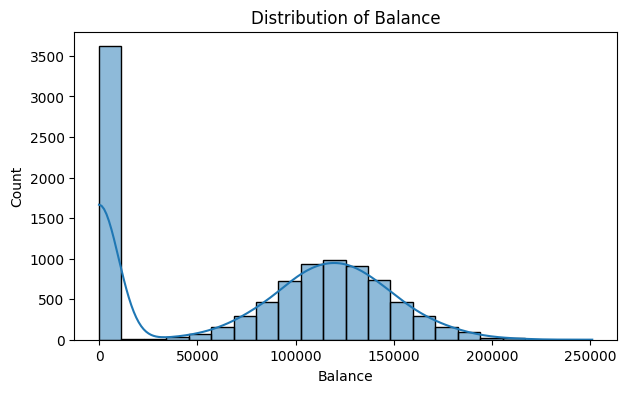

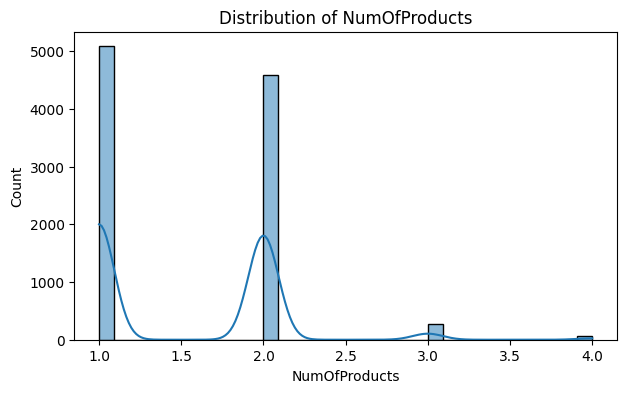

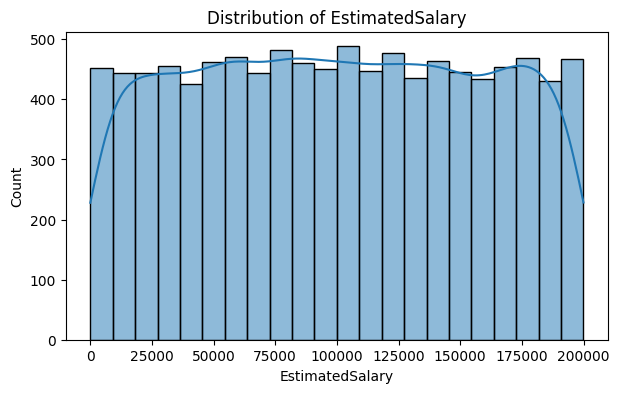

In [48]:
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

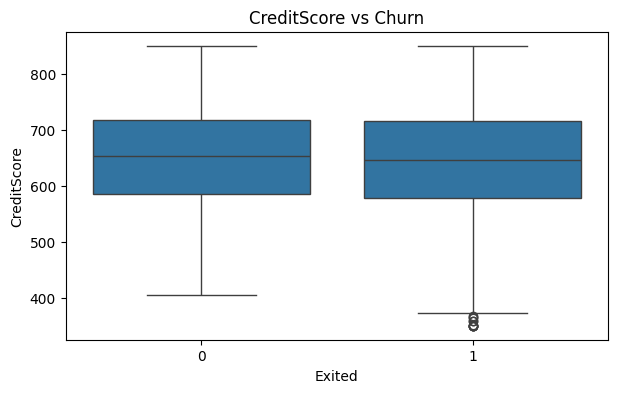

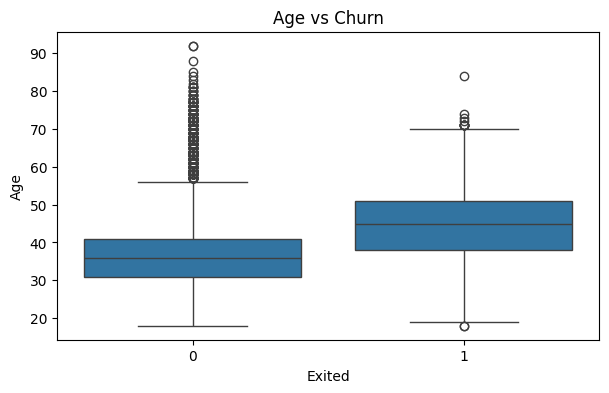

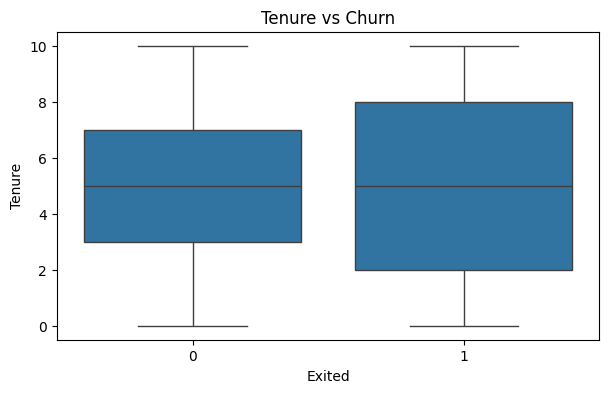

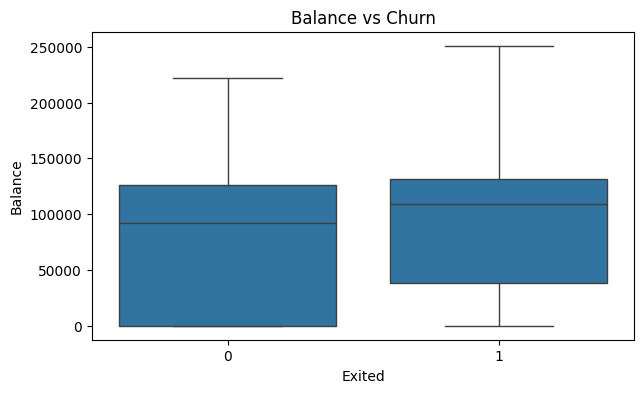

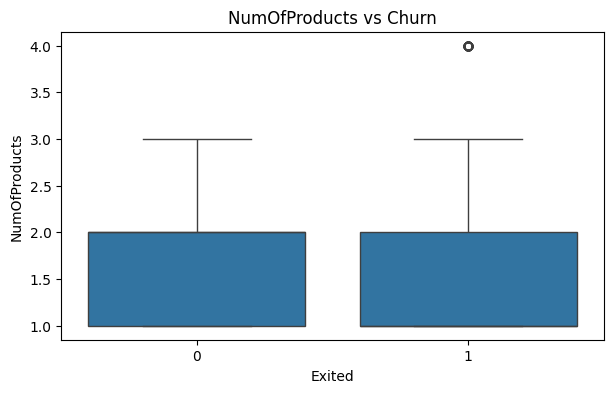

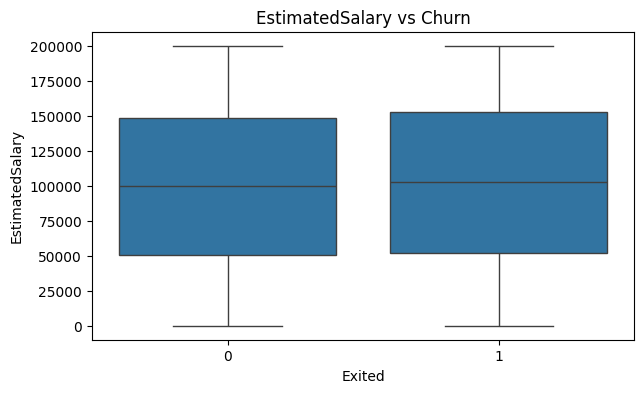

In [49]:
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Exited', y=col)
    plt.title(f'{col} vs Churn')
    plt.show()

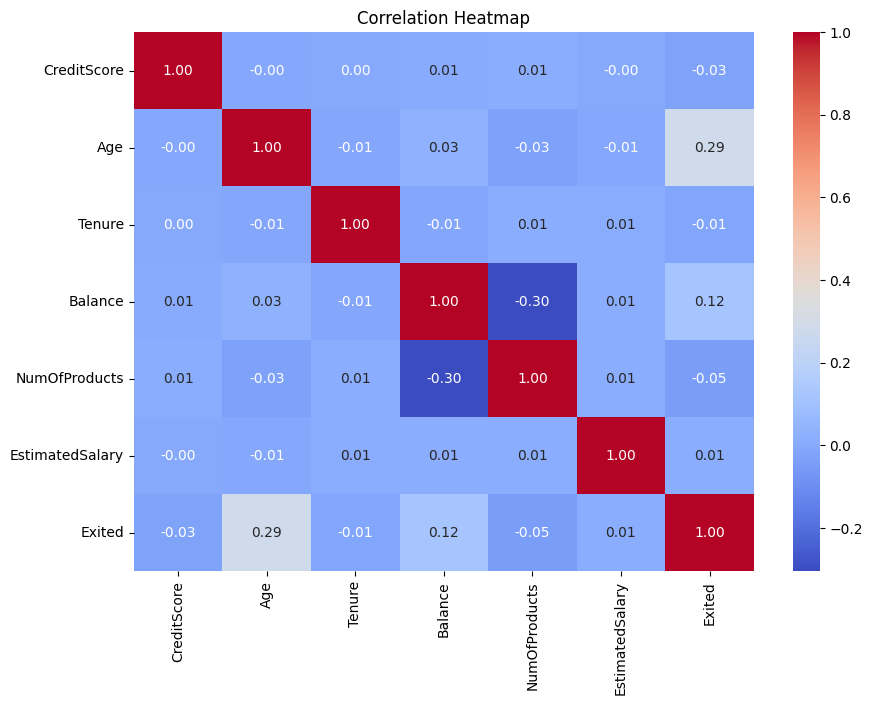

In [50]:
# correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

corr = df[numerical_cols + ['Exited']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [51]:
corr = df[numerical_cols + ['Exited']].corr()

corr['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
Tenure,-0.014001
CreditScore,-0.027094
NumOfProducts,-0.047820


# Key EDA Insights

### 1. Overall Churn

* The overall customer churn rate is approximately **20.37%**, indicating that around one-fifth of the customers have exited.

### 2. Geography-wise Churn

* **Germany** has the highest churn rate compared with France and Spain.
* France and Spain show relatively lower churn rates.

### 3. Gender-wise Churn

* Churn rates between male and female customers show a difference, with female customers having a somewhat higher churn rate in this dataset.

### 4. Age Group-wise Churn

* Churn varies considerably across age groups.
* The **51–65 age group** shows the highest churn rate.
* Younger age groups generally show lower churn rates.

### 5. Active Member-wise Churn

* **Inactive members have a higher churn rate than active members.**
* This suggests that customer engagement is associated with differences in churn levels.

### 6. Number of Products-wise Churn

* Customers with **1 product** have a higher churn rate than customers with 2 products.
* The churn rate is extremely high for customers with **3 and 4 products**.
* These groups should be investigated further along with their customer counts because their sample sizes may be smaller.

### 7. Tenure-wise Churn

* Churn rates vary across different tenure levels, but there is no strong consistent increasing or decreasing pattern.

### 8. Credit Score-wise Churn

* Customers in the **low credit score group** have a somewhat higher churn rate than medium and high credit score groups.
* However, the difference is relatively small.

### 9. Balance-wise Churn

* Churn varies across balance groups.
* The **Low Balance** group shows the highest churn rate among the defined balance categories.
* Customers with no balance show a comparatively lower churn rate.

### 10. Credit Card-wise Churn

* Customers with and without a credit card have very similar churn rates.
* Therefore, credit card ownership does not show a major difference in churn in this analysis.

### 11. Age and Geography Analysis

* Combining age group with geography reveals stronger differences than looking at either variable separately.
* Older customers, particularly in **Germany**, show substantially higher churn rates.

### 12. Age and Active Membership Analysis

* Combining age with active membership shows that **inactive customers in older age groups** have particularly high churn rates.
* The difference between active and inactive customers is especially noticeable in the 51–65 age group.

### 13. Credit Score and Geography Analysis

* Churn patterns vary when credit score groups are analyzed together with geography.
* Geography appears to create differences in churn across credit score groups.

### 14. Balance and Geography Analysis

* Balance-related churn patterns also differ across countries.
* This indicates that balance and geography together provide more detailed customer segmentation than either variable alone.

### 15. Product Count and Active Membership Analysis

* Churn varies when the number of products is considered together with active membership.
* This helps identify customer segments where product count and engagement may jointly be associated with higher churn.

### 16. Numerical Variables: Churned vs Retained Customers

* Churned customers have a higher **average age** than retained customers.
* Churned customers also have a higher **average balance**.
* Average credit score, tenure, number of products and estimated salary show comparatively smaller differences between churned and retained customers.

### 17. Correlation Analysis

* **Age has the strongest positive correlation with churn (0.285)** among the numerical variables analyzed.
* Balance has a weak positive correlation with churn (**0.119**).
* Estimated Salary, Tenure, Credit Score and Number of Products have correlations close to zero with churn.
* Correlation indicates association and does not imply causation.


# Business Recommendations

### 1. Focus on High-Risk Age Groups

* Customers in older age groups, particularly **51–65**, show substantially higher churn rates.
* The bank can consider targeted retention programs, personalized communication, and regular customer engagement for these segments.

### 2. Improve Customer Engagement

* Inactive members have a higher churn rate than active members.
* The bank can use personalized offers, relevant product information, and engagement campaigns to encourage inactive customers to use banking services more regularly.

### 3. Investigate Germany-Specific Churn

* Germany has a substantially higher churn rate than France and Spain.
* The bank should investigate Germany-specific factors such as customer experience, product preferences, service issues, and competitive conditions before designing targeted retention strategies.

### 4. Monitor High-Risk Product Segments

* Customers with **3 or 4 products** show very high observed churn rates.
* These groups should be investigated further, including checking their sample sizes and customer characteristics, before implementing specific retention actions.

### 5. Strengthen Customer Retention for High-Risk Segments

* Customers identified through combinations such as **older age + inactive membership + high-churn geography** can be prioritized for closer monitoring and personalized retention communication.

### 6. Use Customer Segmentation

* Instead of applying the same retention strategy to all customers, the bank can segment customers using factors such as **age, geography, activity status, balance, and number of products**.
* This can help design more targeted customer retention campaigns.

### 7. Monitor Churn Indicators Regularly

* The bank can build a recurring churn monitoring process using customer activity, demographic information, product usage, and account characteristics.
* Regular monitoring can help identify changing churn patterns and support timely retention efforts.


# Conclusion

This customer churn analysis provides insights into the factors associated with customer churn and helps identify customer segments that require greater attention.

The analysis shows an overall churn rate of approximately **20.37%**. Age, geography, customer activity, balance, and number of products show noticeable differences in churn rates across different customer segments. In particular, older customers, inactive members, and customers in Germany show higher observed churn rates.

The correlation analysis also shows that **Age has the strongest positive correlation with churn (0.285)** among the numerical variables analyzed, while Balance has a weaker positive correlation.

These findings can help the bank identify high-risk customer segments, improve customer engagement, and develop more targeted retention strategies. Further analysis using predictive modeling could be used to estimate the churn probability of individual customers.
